### Isabel Nieto - Leonardo Tovar

In [88]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

## 1. Lectura de datos

In [89]:
df = pd.read_excel('Datos1D.xlsx')

In [90]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ingresos  1000 non-null   float64
 1   consumo   1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


,ingresos,consumo
0,44.617090,9.720475
1,73.430827,12.340257
2,5.010866,1.535624
3,33.721594,7.879812
4,18.941810,4.721109


## 2. Modelo polinomial

In [91]:
X_original = df[['ingresos']].values  # (1000, 1)
y = df['consumo'].values               # (1000, 1)
poly = PolynomialFeatures(degree=7)
X = poly.fit_transform(X_original)    # (1000, 8)

print(X)
X.shape

[[1.00000000e+00 4.46170904e+01 1.99068476e+03 ... 1.76809758e+08
  7.88873695e+09 3.51972490e+11]
 [1.00000000e+00 7.34308269e+01 5.39208634e+03 ... 2.13497156e+09
  1.56772727e+11 1.15119510e+13]
 [1.00000000e+00 5.01086561e+00 2.51087741e+01 ... 3.15910292e+03
  1.58298402e+04 7.93212017e+04]
 ...
 [1.00000000e+00 6.85356776e+01 4.69713910e+03 ... 1.51211058e+09
  1.03633523e+11 7.10259375e+12]
 [1.00000000e+00 3.59668847e+01 1.29361679e+03 ... 6.01885822e+07
  2.16479580e+09 7.78609608e+10]
 [1.00000000e+00 7.85753403e+01 6.17408410e+03 ... 2.99523810e+09
  2.35351853e+11 1.84928520e+13]]


(1000, 8)

## 3. Ecuación normal

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

In [93]:
model = LinearRegression()
model.fit(X_train[:, 1:], y_train)  # Excluimos la columna de 1s para que scikit-learn gestione el intercepto

# Evaluación del modelo en el conjunto de prueba
y_pred_test_sklearn = model.predict(X_test[:, 1:])
mse_test_sklearn = mean_squared_error(y_test, y_pred_test_sklearn)

print("Coeficientes del modelo con scikit-learn:", model.coef_.flatten())
print("Intercepto del modelo con scikit-learn:", model.intercept_)
print("Error cuadrático medio en el conjunto de prueba (scikit-learn):", mse_test_sklearn)

Coeficientes del modelo con scikit-learn: [ 2.03378292e-03  2.24368227e-02 -9.88080316e-04  2.24874096e-05
 -2.85951343e-07  1.88513332e-09 -5.01559905e-12]
Intercepto del modelo con scikit-learn: 1.2304039626730852
Error cuadrático medio en el conjunto de prueba (scikit-learn): 0.02682016099895207


In [94]:
# Cálculo de w* usando la ecuación normal
X_train_full = X_train  # Incluye la columna de 1s
w_star = np.linalg.inv(X_train_full.T @ X_train_full) @ X_train_full.T @ y_train

print("w* (ecuación normal):", w_star)

w* (ecuación normal): [ 3.62289285e-01  2.29242004e-01  1.88046267e-03 -1.02346116e-04
  2.09252123e-06 -2.85157489e-08  2.06026075e-10 -5.92799961e-13]


## 4. Función de coste

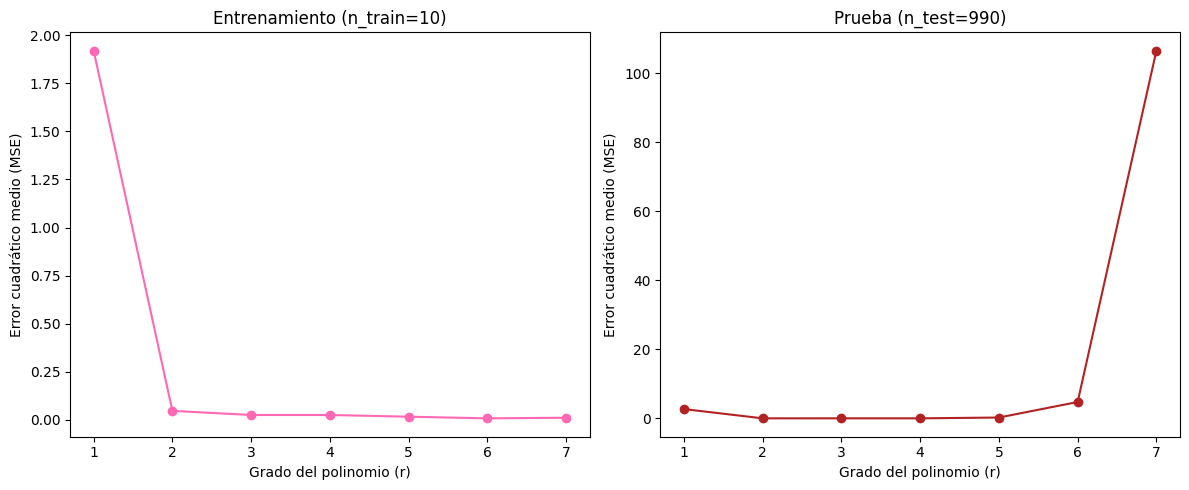

In [107]:
mse_train = []
mse_test = []
grados = list(range(1, 8))
 
for r in grados:
    poly = PolynomialFeatures(degree=r)
    X_poly = poly.fit_transform(X_original)
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.99, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train[:, 1:], y_train)  # Excluimos la columna de 1s
    y_pred_train = model.predict(X_train[:, 1:])
    y_pred_test = model.predict(X_test[:, 1:])
    
    mse_train.append(mean_squared_error(y_train, y_pred_train))
    mse_test.append(mean_squared_error(y_test, y_pred_test))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(grados, mse_train, marker='o', color='hotpink')
axs[0].set_title('Entrenamiento (n_train=10)')
axs[0].set_xlabel('Grado del polinomio (r)')
axs[0].set_ylabel('Error cuadrático medio (MSE)')

axs[1].plot(grados, mse_test, marker='o', color='firebrick')
axs[1].set_title('Prueba (n_test=990)')
axs[1].set_xlabel('Grado del polinomio (r)')
axs[1].set_ylabel('Error cuadrático medio (MSE)')

plt.tight_layout()
plt.show()

## 5. Selección de hiperparámetros 

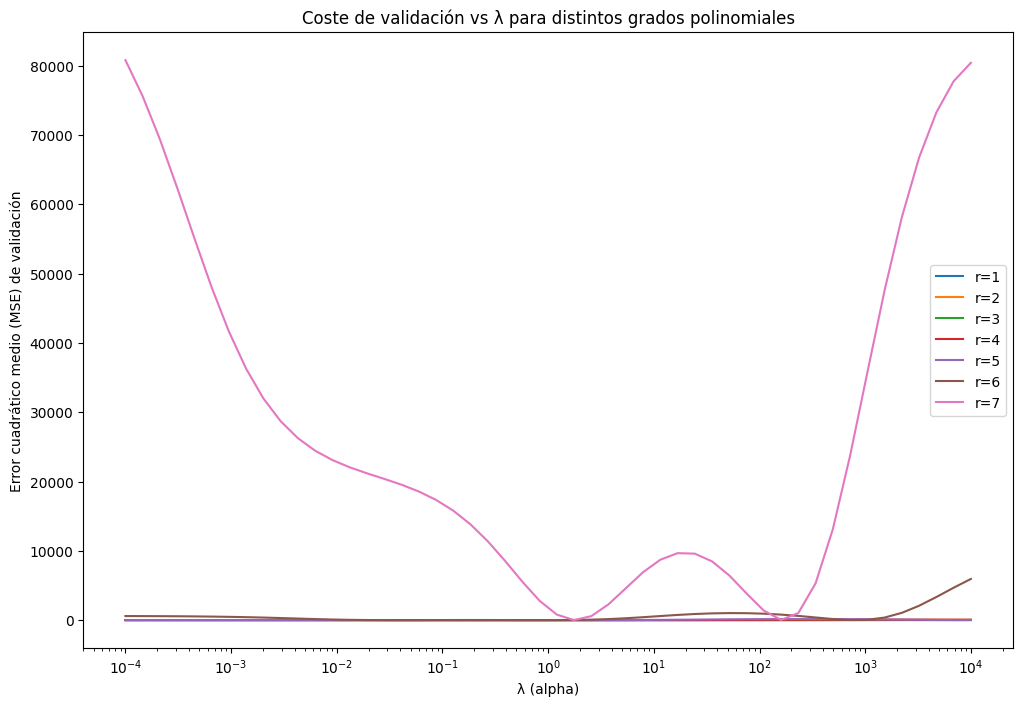

In [96]:
# 1. Divide el conjunto de datos
X_poly = PolynomialFeatures(degree=7).fit_transform(X_original)
n_train, n_val, n_test = 10, 490, 500

X_train, X_val, X_test = X_poly[:n_train], X_poly[n_train:n_train+n_val], X_poly[n_train+n_val:]
y_train, y_val, y_test = y[:n_train], y[n_train:n_train+n_val], y[n_train+n_val:]

lambdas = np.logspace(-4, 4, 50)
grados = range(1, 8)
plt.figure(figsize=(12, 8))

for r in grados:
    poly = PolynomialFeatures(degree=r)
    X_poly = poly.fit_transform(X_original)
    X_train, X_val, X_test = X_poly[:n_train], X_poly[n_train:n_train+n_val], X_poly[n_train+n_val:]
    val_costs = []
    for l in lambdas:
        model = Ridge(alpha=l, fit_intercept=False)
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_costs.append(mean_squared_error(y_val, y_val_pred))
    plt.plot(lambdas, val_costs, label=f"r={r}")

plt.xscale('log')
plt.xlabel('λ (alpha)')
plt.ylabel('Error cuadrático medio (MSE) de validación')
plt.title('Coste de validación vs λ para distintos grados polinomiales')
plt.legend()
plt.show()

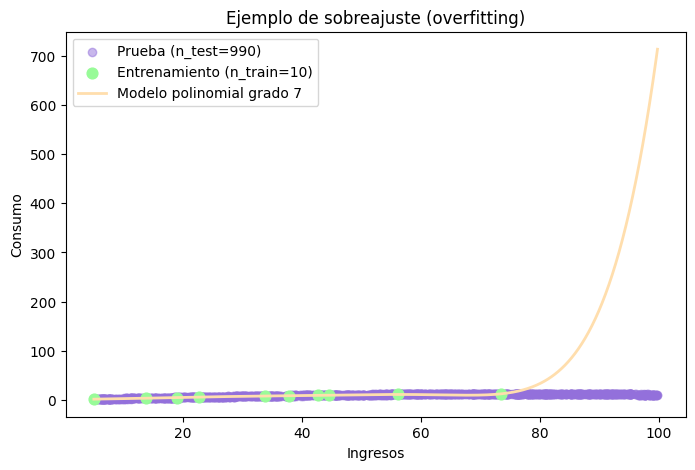

In [106]:
# Divide los datos
n_train, n_test = 10, 990
X_poly = PolynomialFeatures(degree=7).fit_transform(X_original)
X_train, X_test = X_poly[:n_train], X_poly[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Ajusta el modelo polinomial de grado 7
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

# Predicción en todo el rango de ingresos
X_plot = np.linspace(X_original.min(), X_original.max(), 500).reshape(-1, 1)
X_plot_poly = PolynomialFeatures(degree=7).fit_transform(X_plot)
y_plot = model.predict(X_plot_poly)

# Gráfica
plt.figure(figsize=(8, 5))
plt.scatter(X_original[n_train:], y_test, color='mediumpurple', label='Prueba (n_test=990)', alpha=0.5)
plt.scatter(X_original[:n_train], y_train, color='palegreen', label='Entrenamiento (n_train=10)', s=60)
plt.plot(X_plot, y_plot, color='navajowhite', label='Modelo polinomial grado 7', linewidth=2)
plt.xlabel('Ingresos')
plt.ylabel('Consumo')
plt.title('Ejemplo de sobreajuste (overfitting)')
plt.legend()
plt.show()

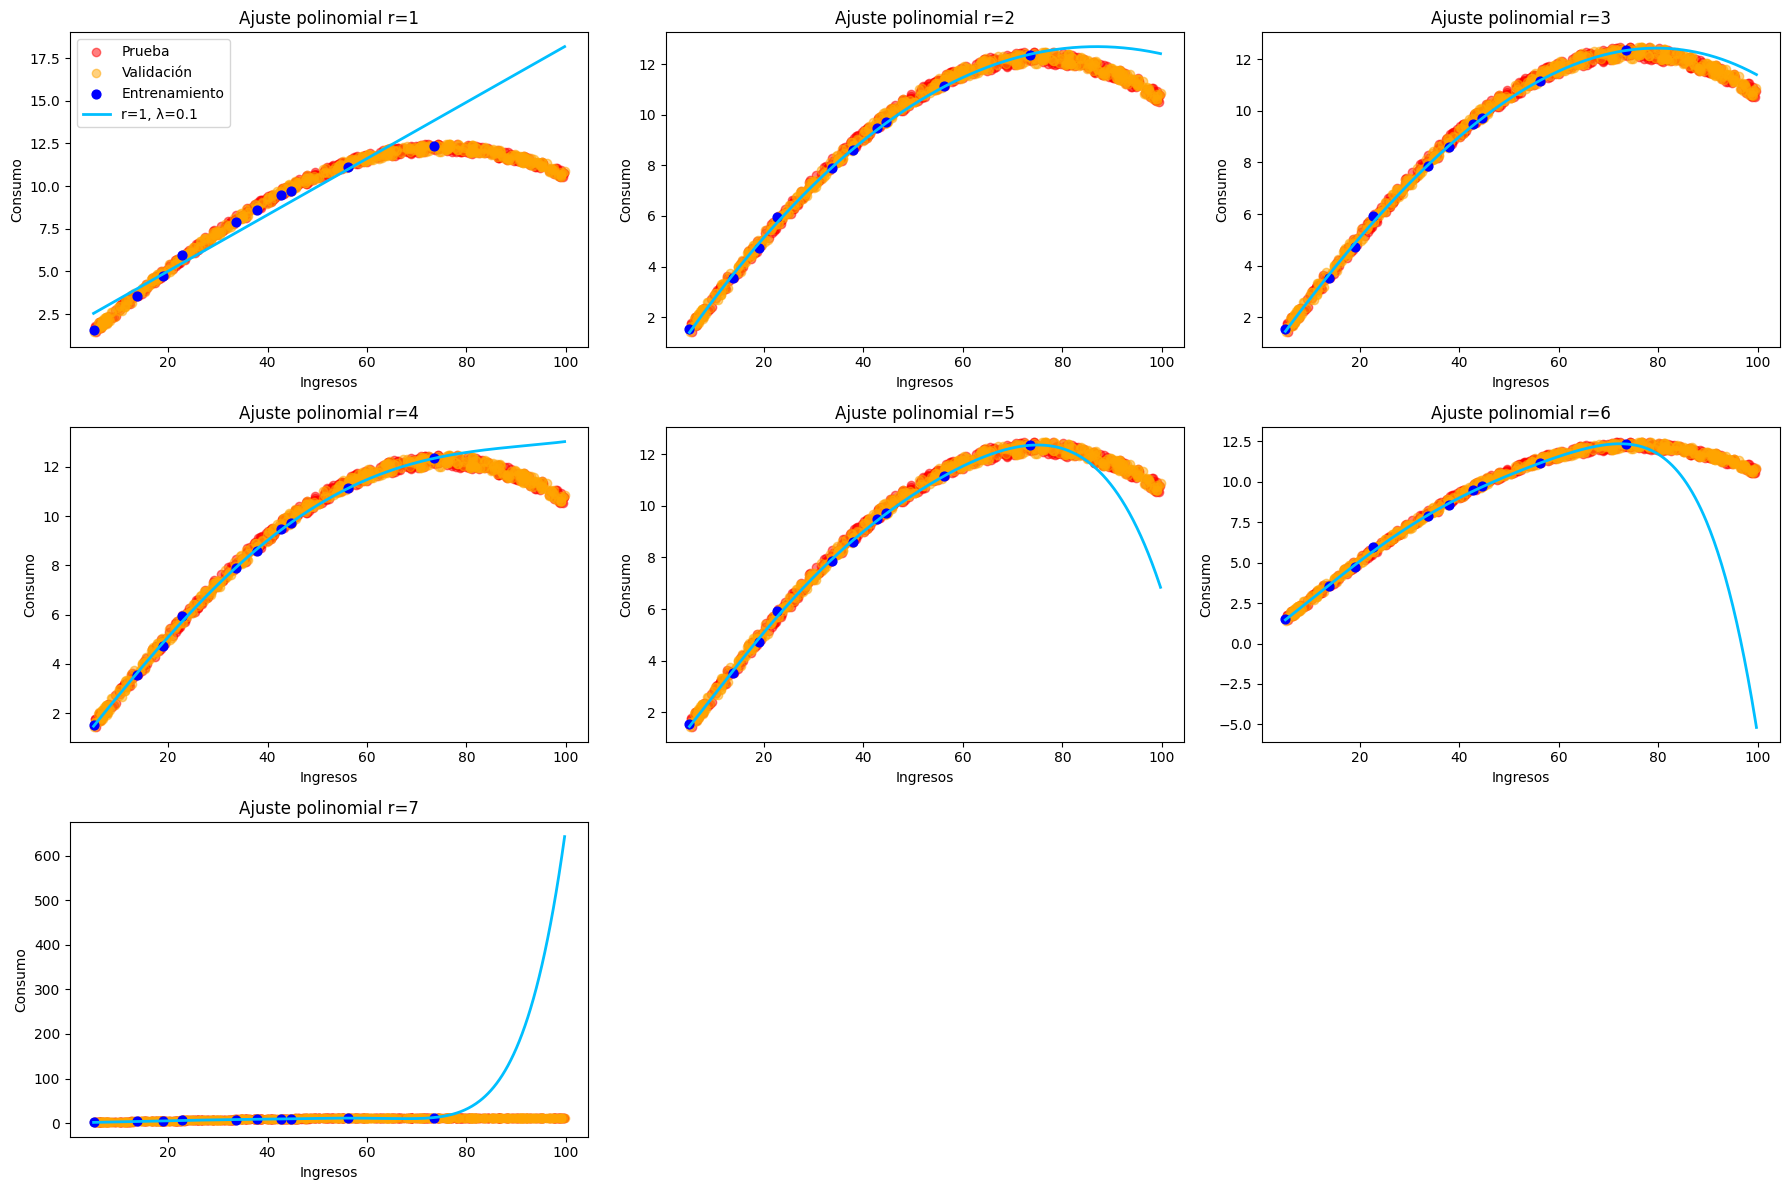

In [111]:
from sklearn.linear_model import Ridge

n_train, n_val, n_test = 10, 490, 500
lambda_val = 0.1

plt.figure(figsize=(18, 12))
for r in range(1, 8):
    poly = PolynomialFeatures(degree=r)
    X_poly = poly.fit_transform(X_original)
    X_train, X_val, X_test = X_poly[:n_train], X_poly[n_train:n_train+n_val], X_poly[n_train+n_val:]
    y_train, y_val, y_test = y[:n_train], y[n_train:n_train+n_val], y[n_train+n_val:]

    model = Ridge(alpha=lambda_val, fit_intercept=False)
    model.fit(X_train, y_train)

    X_plot = np.linspace(X_original.min(), X_original.max(), 500).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    plt.subplot(3, 3, r)
    plt.scatter(X_original[n_train+n_val:], y_test, color='red', label='Prueba', alpha=0.5)
    plt.scatter(X_original[n_train:n_train+n_val], y_val, color='orange', label='Validación', alpha=0.5)
    plt.scatter(X_original[:n_train], y_train, color='blue', label='Entrenamiento', s=40)
    plt.plot(X_plot, y_plot, color='deepskyblue', label=f'r={r}, λ={lambda_val}', linewidth=2)
    plt.xlabel('Ingresos')
    plt.ylabel('Consumo')
    plt.title(f'Ajuste polinomial r={r}')
    if r == 1:
        plt.legend()

plt.tight_layout()
plt.show()

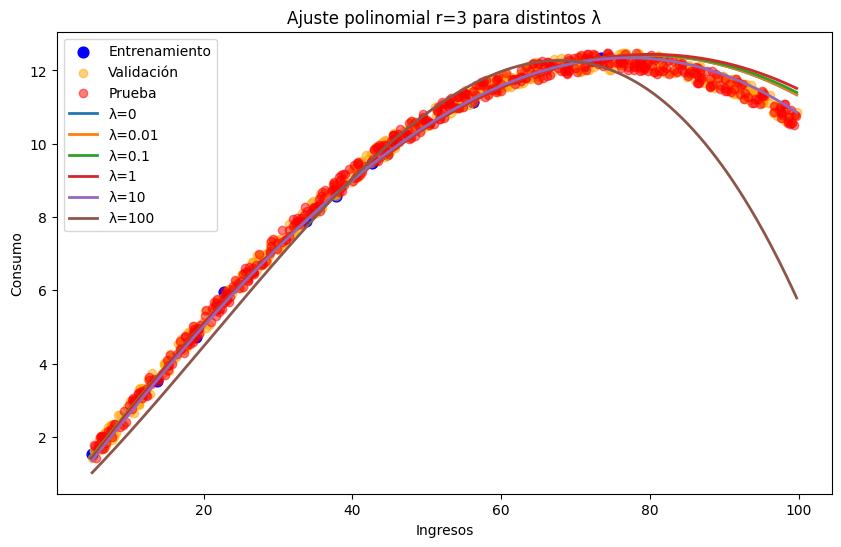

In [99]:
from sklearn.linear_model import Ridge

n_train, n_val, n_test = 10, 490, 500
lambdas = [0, 0.01, 0.1, 1, 10, 100]
r = 3

poly = PolynomialFeatures(degree=r)
X_poly = poly.fit_transform(X_original)
X_train, X_val, X_test = X_poly[:n_train], X_poly[n_train:n_train+n_val], X_poly[n_train+n_val:]
y_train, y_val, y_test = y[:n_train], y[n_train:n_train+n_val], y[n_train+n_val:]

X_plot = np.linspace(X_original.min(), X_original.max(), 500).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_original[:n_train], y_train, color='blue', label='Entrenamiento', s=60)
plt.scatter(X_original[n_train:n_train+n_val], y_val, color='orange', label='Validación', alpha=0.5)
plt.scatter(X_original[n_train+n_val:], y_test, color='red', label='Prueba', alpha=0.5)

for l in lambdas:
    model = Ridge(alpha=l, fit_intercept=False)
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot_poly)
    plt.plot(X_plot, y_plot, label=f'λ={l}', linewidth=2)

plt.xlabel('Ingresos')
plt.ylabel('Consumo')
plt.title('Ajuste polinomial r=3 para distintos λ')
plt.legend()
plt.show()

In [100]:
from sklearn.linear_model import Ridge

n_train, n_val, n_test = 10, 490, 500
lambdas = np.logspace(-4, 4, 50)
grados = range(1, 8)

mejor_mse = float('inf')
mejor_r = None
mejor_lambda = None

for r in grados:
    poly = PolynomialFeatures(degree=r)
    X_poly = poly.fit_transform(X_original)
    X_train, X_val, X_test = X_poly[:n_train], X_poly[n_train:n_train+n_val], X_poly[n_train+n_val:]
    y_train, y_val, y_test = y[:n_train], y[n_train:n_train+n_val], y[n_train+n_val:]
    for l in lambdas:
        model = Ridge(alpha=l, fit_intercept=False)
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        mse = mean_squared_error(y_val, y_val_pred)
        if mse < mejor_mse:
            mejor_mse = mse
            mejor_r = r
            mejor_lambda = l

print(f"Mejor combinación: r={mejor_r}, lambda={mejor_lambda:.4f}, MSE de validación={mejor_mse:.4f}")

Mejor combinación: r=3, lambda=11.5140, MSE de validación=0.0367


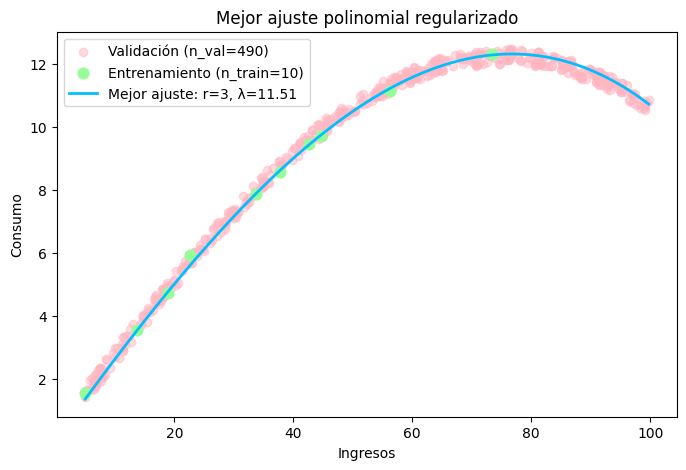

In [ ]:
from sklearn.linear_model import Ridge

# Selecciona el mejor grado y lambda encontrados visualmente (ajusta si es necesario)
mejor_r = 3
mejor_lambda = 11.51

# Prepara los datos
poly = PolynomialFeatures(degree=mejor_r)
X_poly = poly.fit_transform(X_original)
n_train, n_val, n_test = 10, 490, 500
X_train, X_val, X_test = X_poly[:n_train], X_poly[n_train:n_train+n_val], X_poly[n_train+n_val:]
y_train, y_val, y_test = y[:n_train], y[n_train:n_train+n_val], y[n_train+n_val:]

# Ajusta el modelo Ridge con el mejor lambda
model = Ridge(alpha=mejor_lambda, fit_intercept=False)
model.fit(X_train, y_train)

# Predicción para graficar la curva
X_plot = np.linspace(X_original.min(), X_original.max(), 500).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

# Gráfica
plt.figure(figsize=(8, 5))
plt.scatter(X_original[n_train:n_train+n_val], y_val, color='lightpink', label='Validación (n_val=490)', alpha=0.5)
plt.scatter(X_original[:n_train], y_train, color='palegreen', label='Entrenamiento (n_train=10)', s=60)
#plt.scatter(X_original[n_train+n_val:], y_test, color='red', label='Prueba (n_test=500)', alpha=0.5)
plt.plot(X_plot, y_plot, color='deepskyblue', label=f'Mejor ajuste: r={mejor_r}, λ={mejor_lambda}', linewidth=2)
plt.xlabel('Ingresos')
plt.ylabel('Consumo')
plt.title('Mejor ajuste polinomial regularizado')
plt.legend()
plt.show()